## 7.9 변분 양자 고유값 풀개(VQE)를 이용한 전자구조 계산

In [1]:
# Qiskit 라이브러리 임포트
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_city
from qiskit_algorithms import VQE
from qiskit.circuit.library import EfficientSU2
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from qiskit_algorithms.optimizers import COBYLA
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 분자 해밀토니안 생성 (H2 예시)
# H2 분자를 단순화한 파울리 연산자 정의
pauli_list = [SparsePauliOp.from_list([("II", -1.052373245772859), ("IZ", 0.39793742484318045),
                                       ("ZI", -0.39793742484318045), ("ZZ", -0.01128010425623538),
                                       ("XX", 0.18093119978423156)])]

In [3]:
# VQE용 양자회로 앤사츠 정의 (EfficientSU2)
num_qubits = 2
ansatz = EfficientSU2(num_qubits)

/sessions/eloquent-vigilant-lovelace/tmp/ipykernel_70/1749071233.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits)


In [4]:
# VQE 솔버용 최적화기 정의
optimizer = COBYLA(maxiter=100)

In [5]:
# 시뮬레이터 초기화
simulator = AerSimulator()

In [6]:
# 바닥상태 탐색
vqe = VQE(StatevectorEstimator(), ansatz, optimizer)  # 호환성 수정: V2 추정기
vqe_result = vqe.compute_minimum_eigenvalue(operator=pauli_list[0])

print(f"계산된 바닥상태 에너지: {vqe_result.eigenvalue.real}")

계산된 바닥상태 에너지: -1.8571857804319418


In [7]:
# 시각화를 위해 앤사츠에 파라미터 결합
params = np.random.rand(ansatz.num_parameters_settable)
qc = ansatz.assign_parameters(params)

In [8]:
# AerSimulator용으로 앤사츠를 표준 게이트로 분해
qc = qc.decompose()

In [9]:
# 상태 시뮬레이션
qc.save_statevector()  # 이후 회수를 위해 상태벡터 저장
job = simulator.run(qc)
result = job.result()

In [10]:
# 결과에서 상태벡터 회수
state = result.get_statevector(qc)  # 회로를 명시

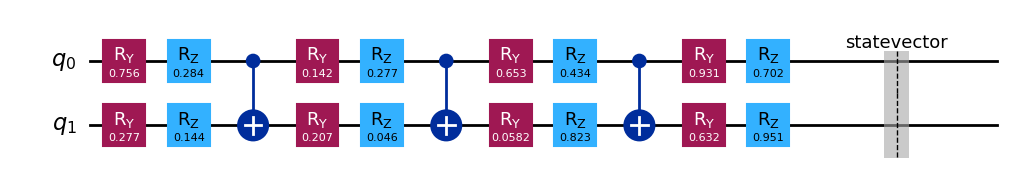

In [11]:
# MPL 회로도
qc.draw(output='mpl')
plt.show()

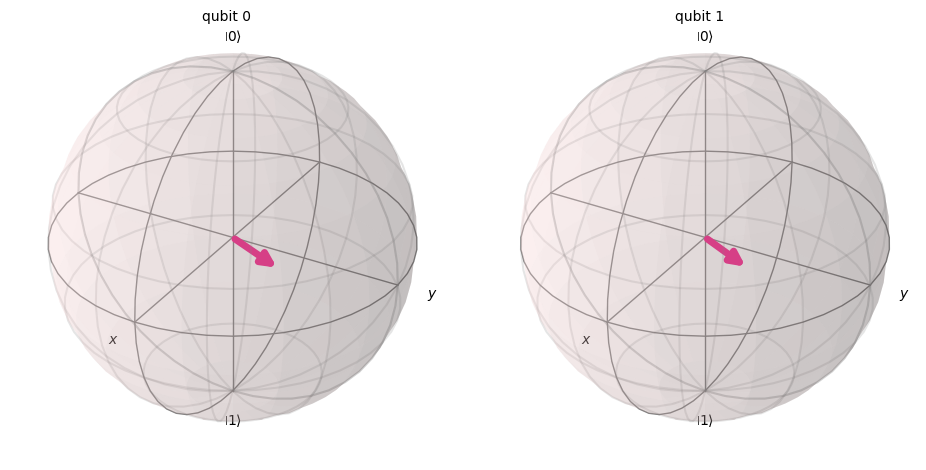

In [12]:
# 블로흐 구 시각화
statevector = Statevector(state)
plot_bloch_multivector(statevector)
plt.show()

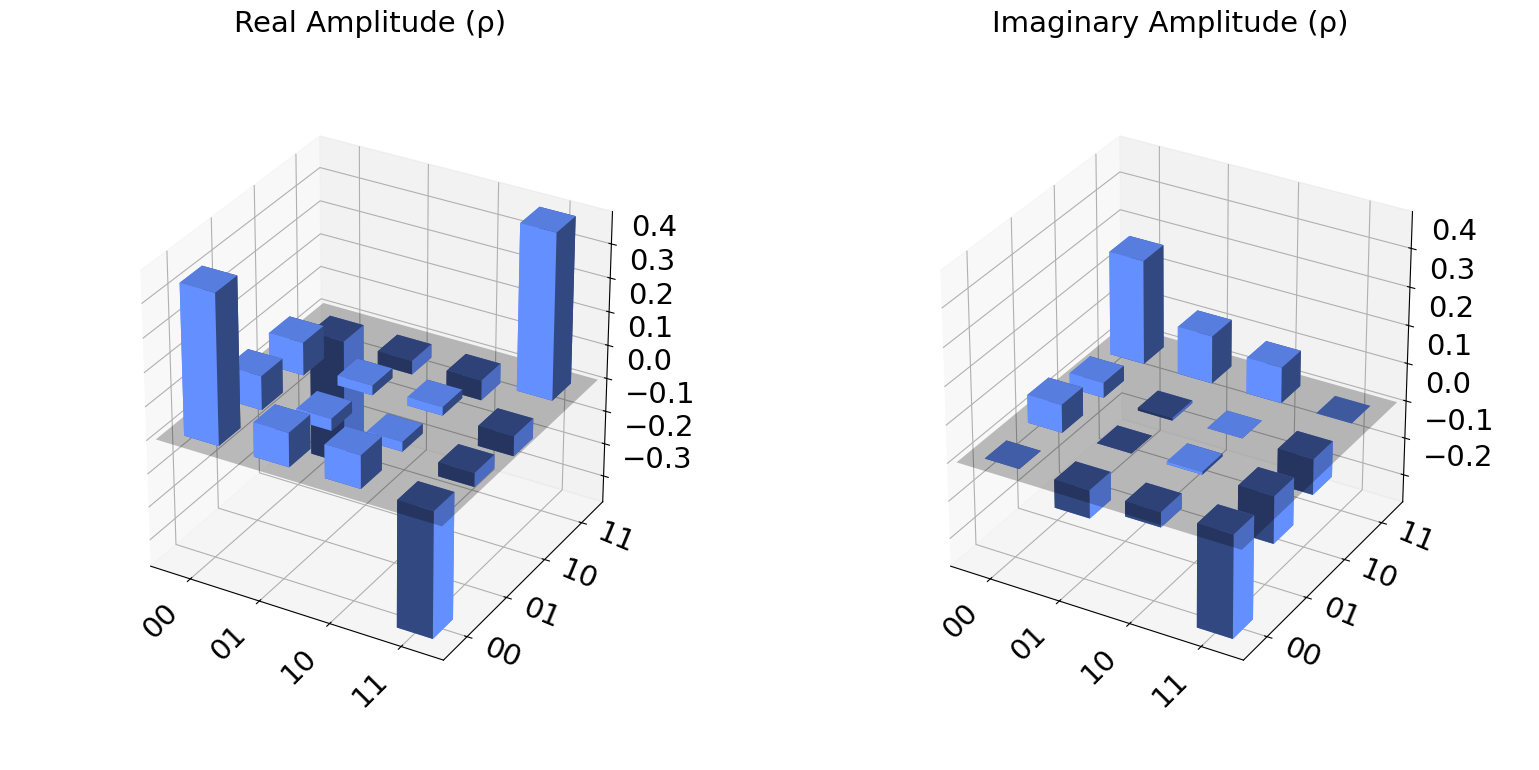

In [13]:
# State City 시각화
plot_state_city(statevector)
plt.show()

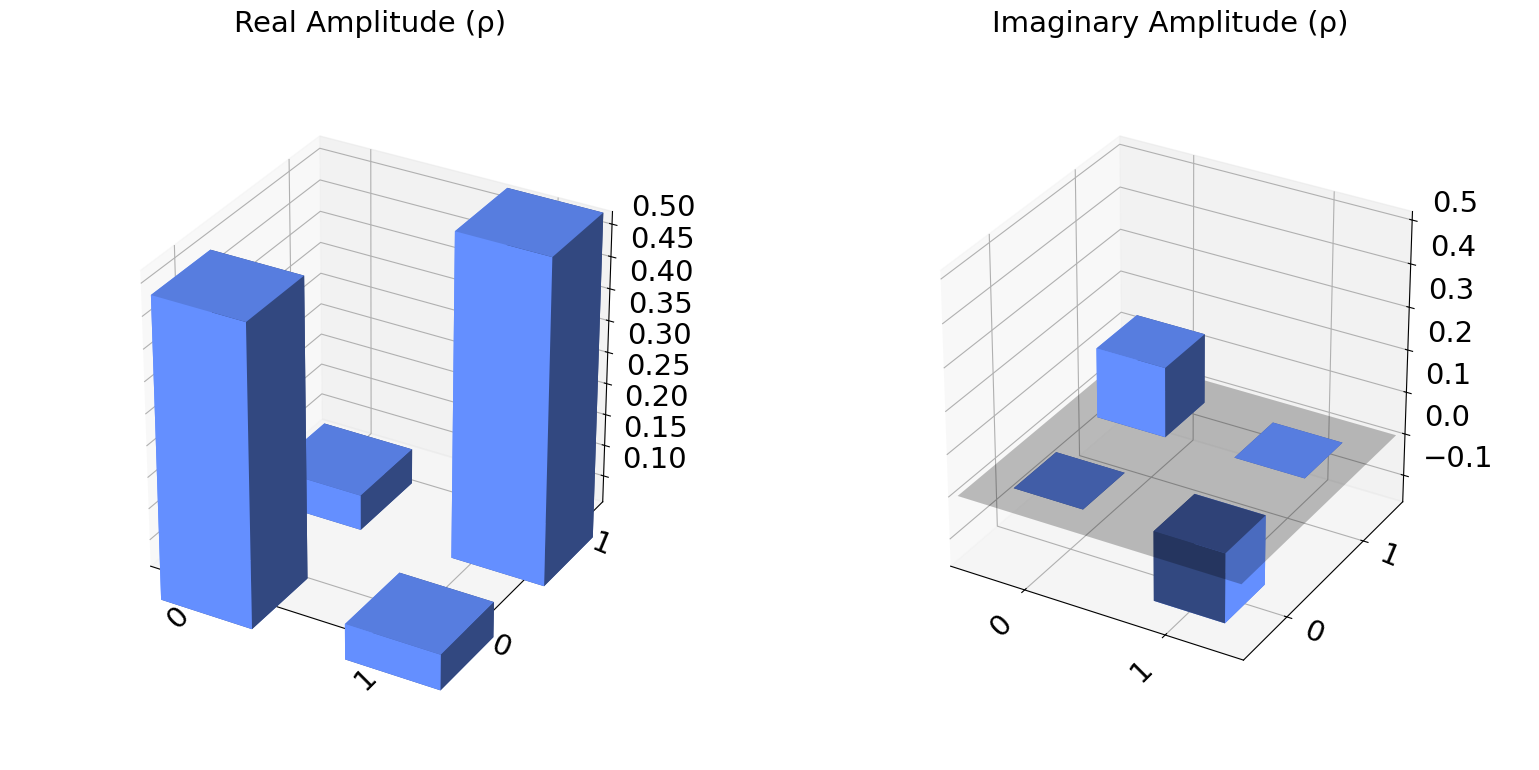

In [14]:
# 부분 대각합 (축소 밀도행렬)
reduced_density_matrix = partial_trace(statevector, [0])
plot_state_city(reduced_density_matrix)
plt.show()

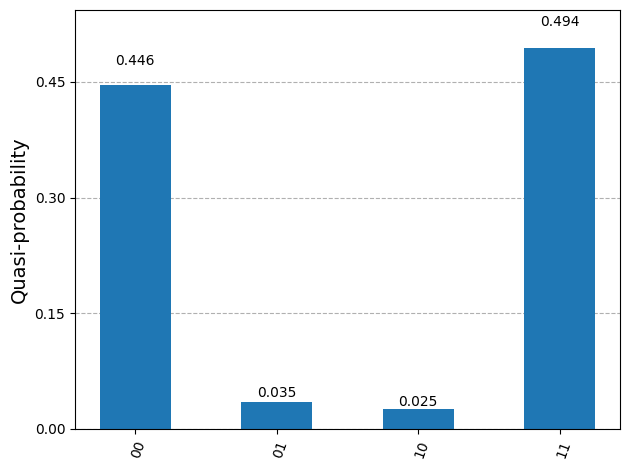

In [15]:
# 측정 결과 히스토그램
counts = result.get_counts(qc)
plot_histogram(counts)
plt.show()

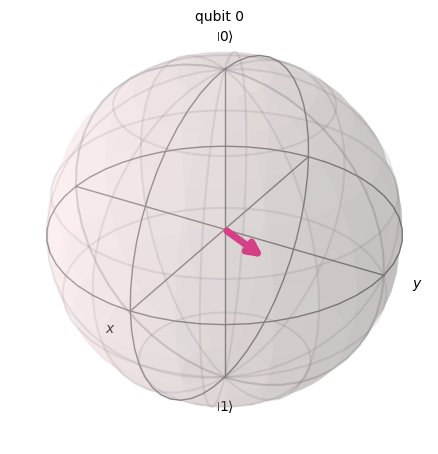

In [16]:
# 부분 대각합 블로흐 구 (축소 큐비트 상태 시각화)
plot_bloch_multivector(reduced_density_matrix)
plt.show()